# 🎓 University Admission Prediction 
**Goal:** Predicting admission chances and analyzing Model Overfitting vs. Optimal Fit.

## 1. Exploratory Data Analysis (EDA) & Preprocessing
Loading data, checking missing values, and exploring feature correlations.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df_original= pd.read_csv(r'D:\DEPI 2025-2026\MLOps\ML\Decision_Tree_Overfitting_Analysis\Admission_Predict.csv')
df=df_original.copy()
df_poly=df_original.copy()
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


Exploratory Data Analysis (EDA)

In [4]:
df.describe()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,200.500000,316.807500,107.410000,3.087500,3.400000,3.452500,8.598925,0.547500,0.724350
std,115.614301,11.473646,6.069514,1.143728,1.006869,0.898478,0.596317,0.498362,0.142609
min,1.000000,290.000000,92.000000,1.000000,1.000000,1.000000,6.800000,0.000000,0.340000
25%,100.750000,308.000000,103.000000,2.000000,2.500000,3.000000,8.170000,0.000000,0.640000
50%,200.500000,317.000000,107.000000,3.000000,3.500000,3.500000,8.610000,1.000000,0.730000
75%,300.250000,325.000000,112.000000,4.000000,4.000000,4.000000,9.062500,1.000000,0.830000
max,400.000000,340.000000,120.000000,5.000000,5.000000,5.000000,9.920000,1.000000,0.970000


In [5]:
df.isnull().sum()

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64

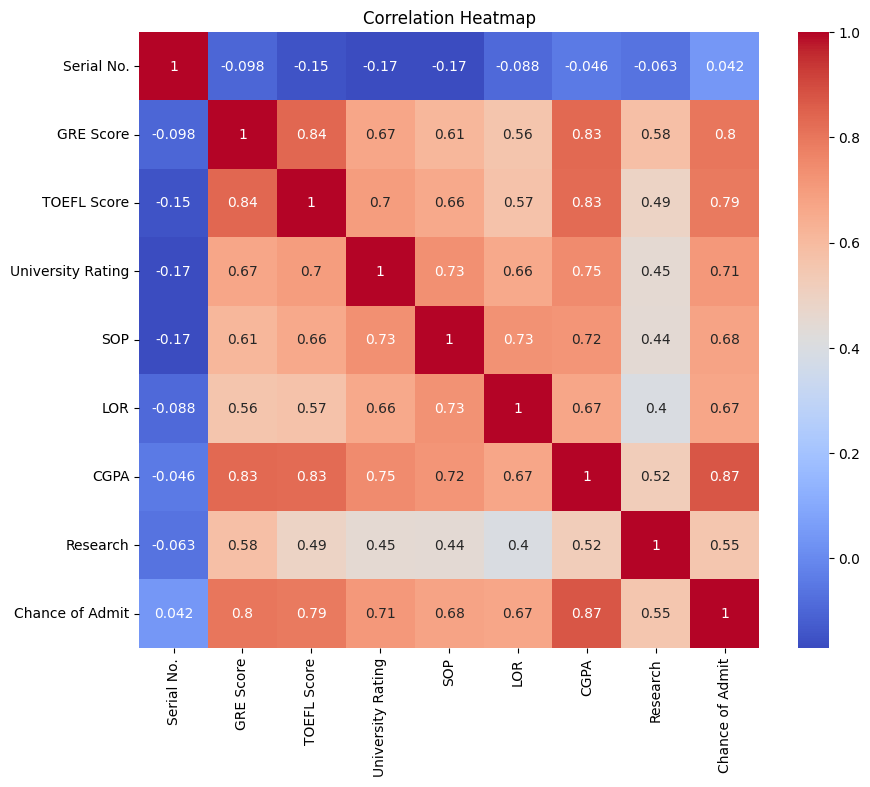

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Preprocessing

In [7]:
df = df.drop('Serial No.', axis=1)
df.shape

(400, 8)

In [8]:
df['Chance of Admit'] = df['Chance of Admit']>=0.75
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,True
1,324,107,4,4.0,4.5,8.87,1,True
2,316,104,3,3.0,3.5,8.00,1,False
3,322,110,3,3.5,2.5,8.67,1,True
4,314,103,2,2.0,3.0,8.21,0,False
...,...,...,...,...,...,...,...,...
395,324,110,3,3.5,3.5,9.04,1,True
396,325,107,3,3.0,3.5,9.11,1,True
397,330,116,4,5.0,4.5,9.45,1,True
398,312,103,3,3.5,4.0,8.78,0,False


## 2. The Overfitting Problem 🪤
Demonstrating how unconstrained models memorize data and fail on unseen testing data.
* **Experiment A:** Unpruned Decision Tree (High variance).
* **Experiment B:** Polynomial Regression (Feature explosion).

Training Accuracy: 1.0
Testing Accuracy: 0.8625


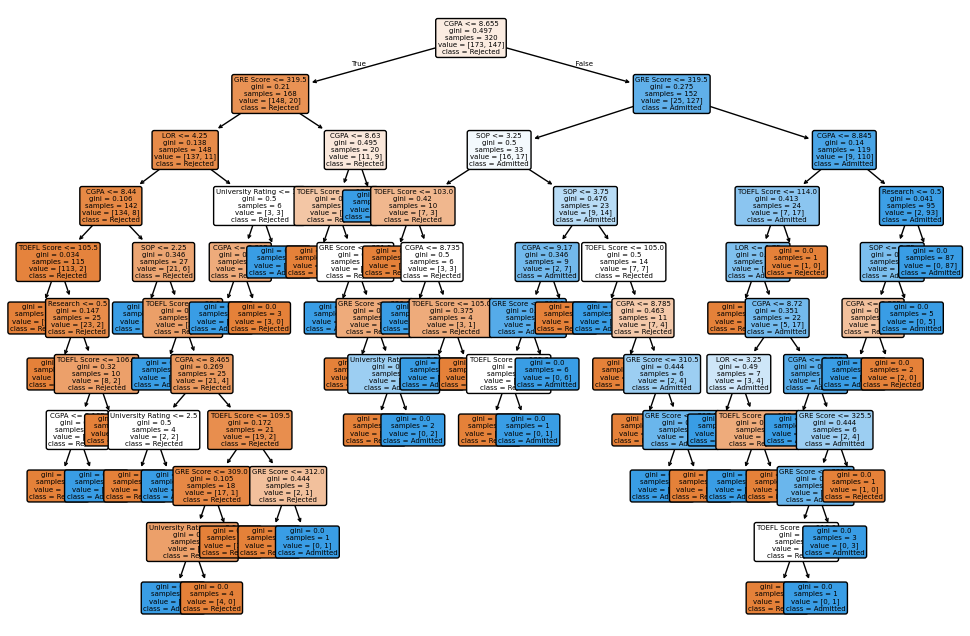

In [9]:
#Experiment A : Unpruned Decision Tree (High variance).
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
model_tree.fit(X_train, y_train)

print(f"Training Accuracy: {model_tree.score(X_train, y_train)}")
print(f"Testing Accuracy: {model_tree.score(X_test, y_test)}")

from sklearn.tree import plot_tree
plt.figure(figsize=(12,8))
plot_tree(model_tree, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Rejected', 'Admitted'], 
          rounded=True,
          fontsize=5) 
plt.show()

In [10]:
#Experiment B : Polynomial Regression (Feature explosion).
X_poly = df_poly.drop('Chance of Admit', axis=1)
y_poly = df_poly['Chance of Admit']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)
poly = PolynomialFeatures(degree=3, include_bias=False)
X_train_poly = poly.fit_transform(X_train_p)
X_test_poly = poly.transform(X_test_p)

poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train_p)

train_preds = poly_model.predict(X_train_poly)
test_preds = poly_model.predict(X_test_poly)

print(f"Training Score (R2): {r2_score(y_train_p, train_preds):.4f}")
print(f"Testing Score (R2): {r2_score(y_test_p, test_preds):.4f}")

Training Score (R2): 0.9233
Testing Score (R2): 0.4236


## 3. The Solutions 🛠️
Applying regularization and ensemble methods to build generalized models.
* **Solution A:** Pruning the Decision Tree (`max_depth=6`) for stable Classification.
* **Solution B:** Random Forest Regressor (100 Trees) for stable Regression.

Training Accuracy: 0.953125
Testing Accuracy: 0.9


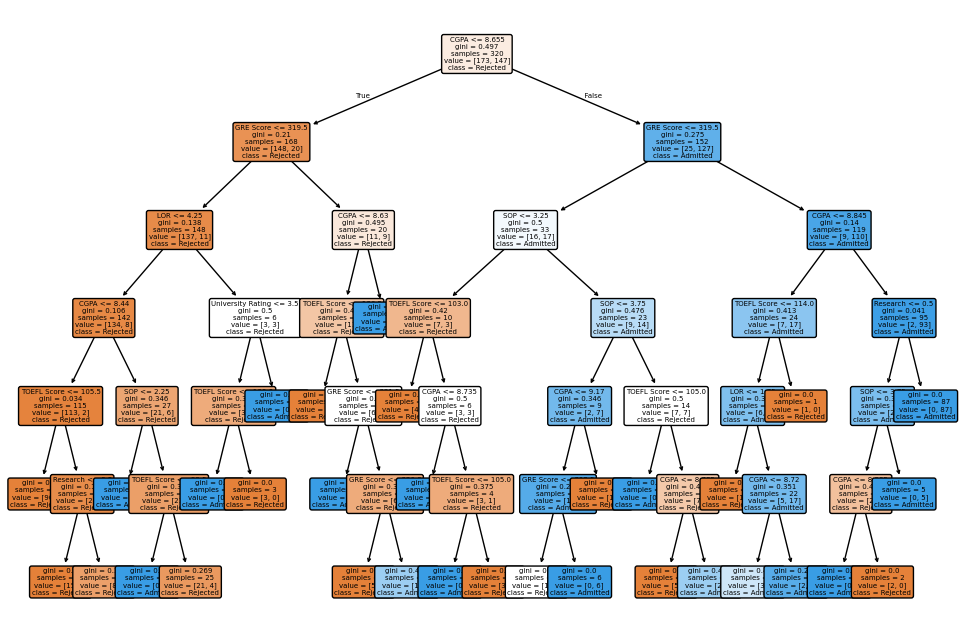

In [11]:
#Solution A : Pruning the Decision Tree (`max_depth=6`) for stable Classification.
X = df.drop('Chance of Admit', axis=1)
y = df['Chance of Admit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_depth = DecisionTreeClassifier(max_depth=6,criterion='gini', random_state=42)
model_depth.fit(X_train, y_train)

print(f"Training Accuracy: {model_depth.score(X_train, y_train)}")
print(f"Testing Accuracy: {model_depth.score(X_test, y_test)}")


plt.figure(figsize=(12,8))
plot_tree(model_depth, 
          filled=True, 
          feature_names=X.columns, 
          class_names=['Rejected', 'Admitted'], 
          rounded=True,
          fontsize=5) 
plt.show()

In [12]:
#Solution B : Random Forest Regressor (100 Trees) for stable Regression.
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)

rf_model.fit(X_train_p, y_train_p)

rf_train_preds = rf_model.predict(X_train_p)
rf_test_preds = rf_model.predict(X_test_p)

print(f"Training Score (R2): {r2_score(y_train_p, rf_train_preds):.4f}")
print(f"Testing Score (R2): {r2_score(y_test_p, rf_test_preds):.4f}")

Training Score (R2): 0.9122
Testing Score (R2): 0.8537


## For Deploy

In [13]:
import joblib

joblib.dump(model_depth, 'admission_model.pkl')

print("Model saved successfully! 🎉")

Model saved successfully! 🎉
